# FlyVis 模型参数分析 (Parameter Analysis)

本 Notebook 分析 FlyVis 网络的参数分布，包括：
- **时间常数 τ** (time_const)：每个 neuron type 共享，初始值 0.05 s
- **Bias** (resting potential)：每个 type 从 N(0.5, 0.05) 采样
- **Synapse Strength** (syn_strength)：每个 (src, tgt) type pair 共享
- **Synapse Count** (syn_count)：包含空间偏移 (du, dv)
- **Sign**：固定的 ±1（激励/抑制）

### 参数配置
| 参数 | 类型 | groupby | 初始分布 | requires_grad |
|------|------|---------|----------|---------------|
| `time_const` | TimeConstant | type | Value(0.05 s) | ✓ |
| `bias` | RestingPotential | type | Normal(0.5, 0.05) | ✓ |
| `syn_strength` | SynapseCountScaling | src, tgt | scale=0.01 | ✓ |
| `syn_count` | SynapseCount | src, tgt, du, dv | Lognormal | ✗ |
| `sign` | SynapseSign | src, tgt | fixed ±1 | ✗ |


In [1]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Run the analysis script (generates all plots to outputs/)
%run param_analysis.py


Importing flyvis...


ModuleNotFoundError: No module named 'dotenv'

## 生成的图表 (Generated Plots)

### 1. 时间常数 τ 分布
左：各 neuron type 的 τ 值（初始化时全部为 0.05 s）；右：整体分布直方图

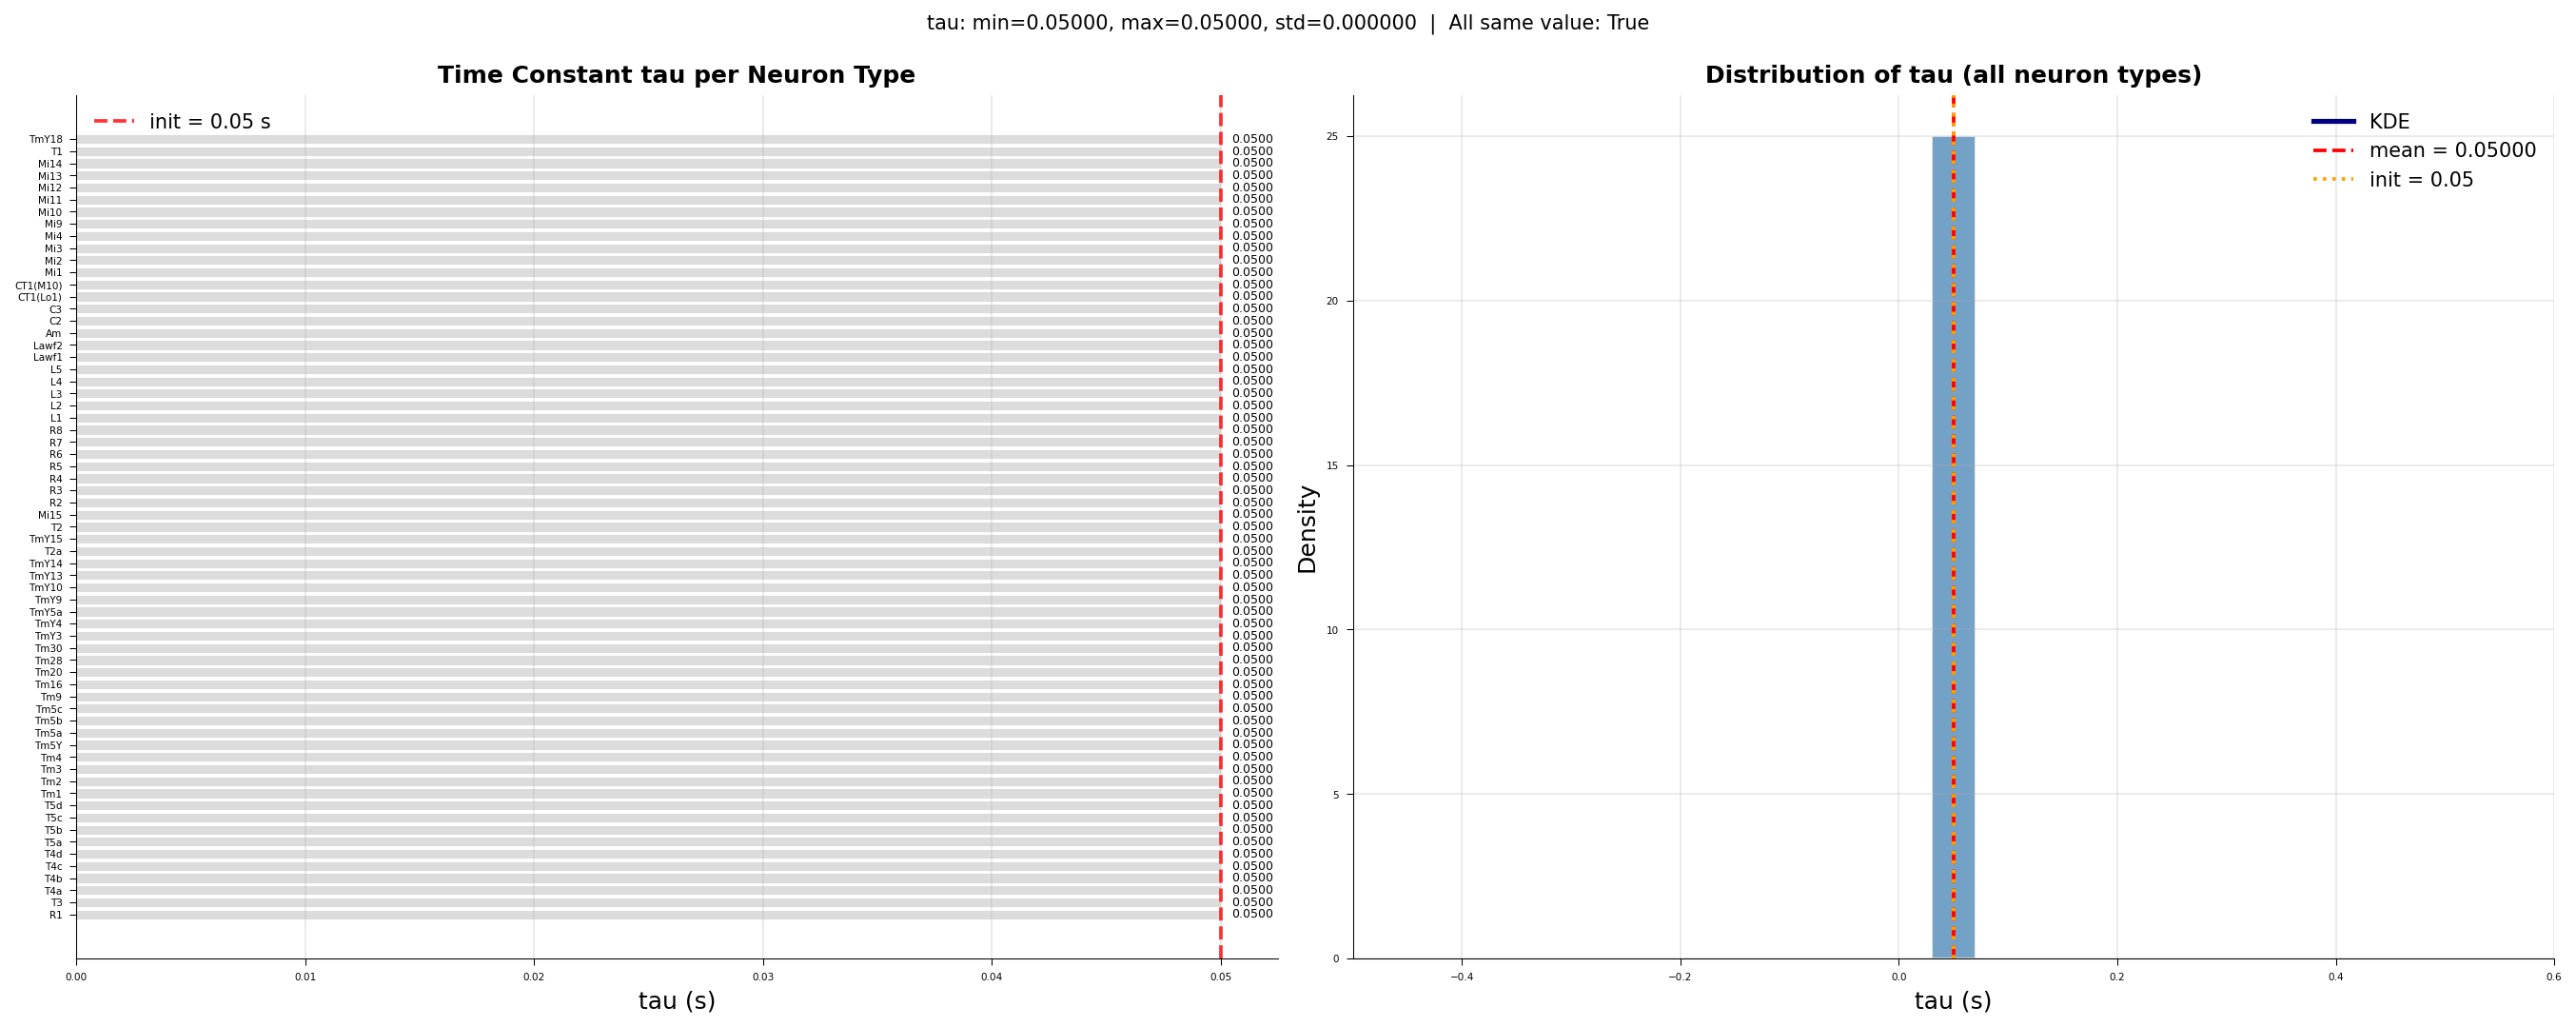

In [2]:
from IPython.display import Image
Image('outputs/01_tau_distribution.png', width=900)


### 2. Bias (Resting Potential) 分布
每个 type 从 N(0.5, 0.05) 初始化，type 间有差异

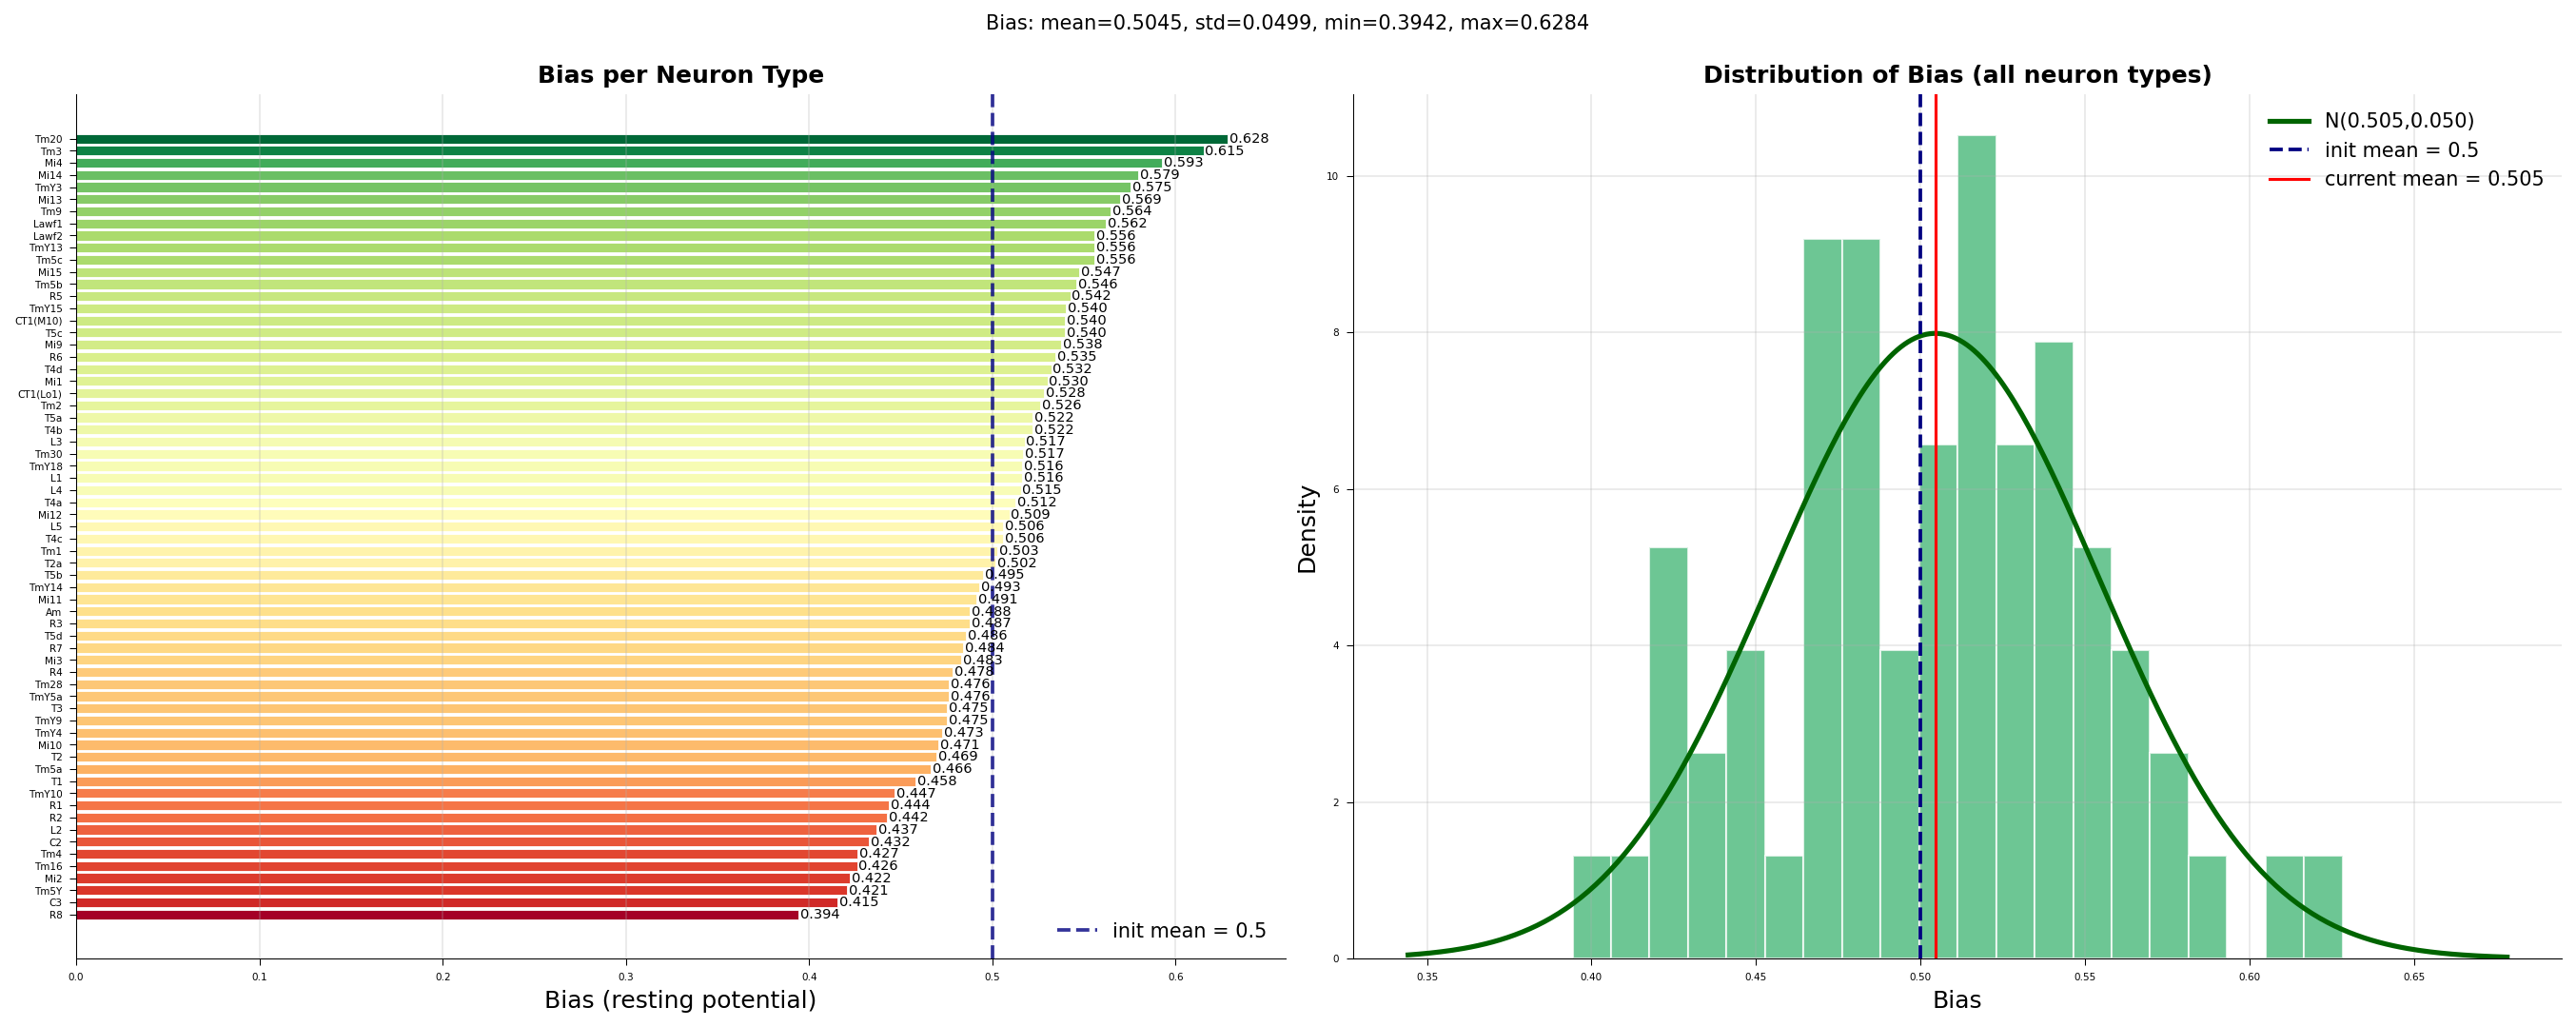

In [3]:
from IPython.display import Image
Image('outputs/02_bias_distribution.png', width=900)


### 3. τ vs Bias 散点图
横轴 τ，纵轴 bias，每点一个 neuron type

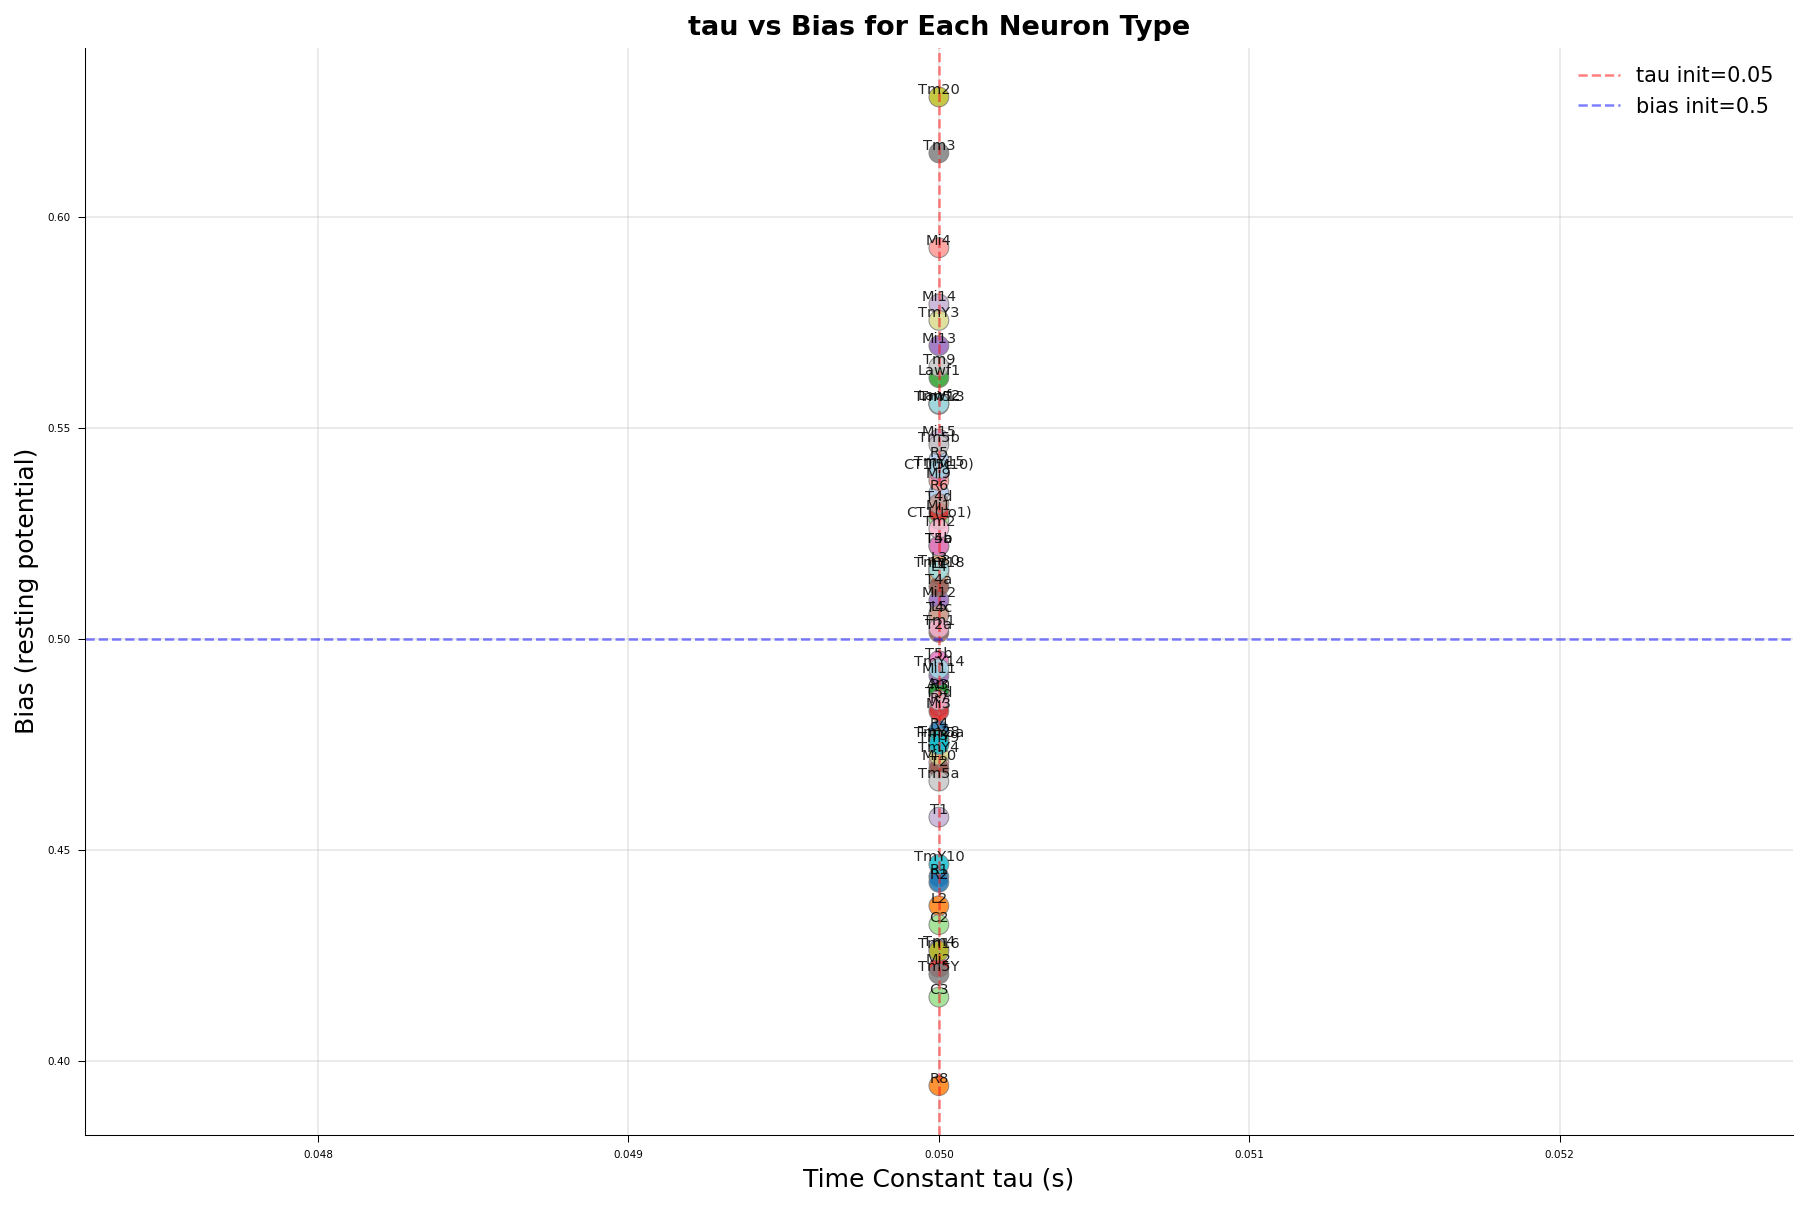

In [4]:
from IPython.display import Image
Image('outputs/03_tau_vs_bias_scatter.png', width=900)


### 4. Synapse Strength 整体分布
左：所有 (src,tgt) pair 的 strength；右：按 excitatory/inhibitory 分组

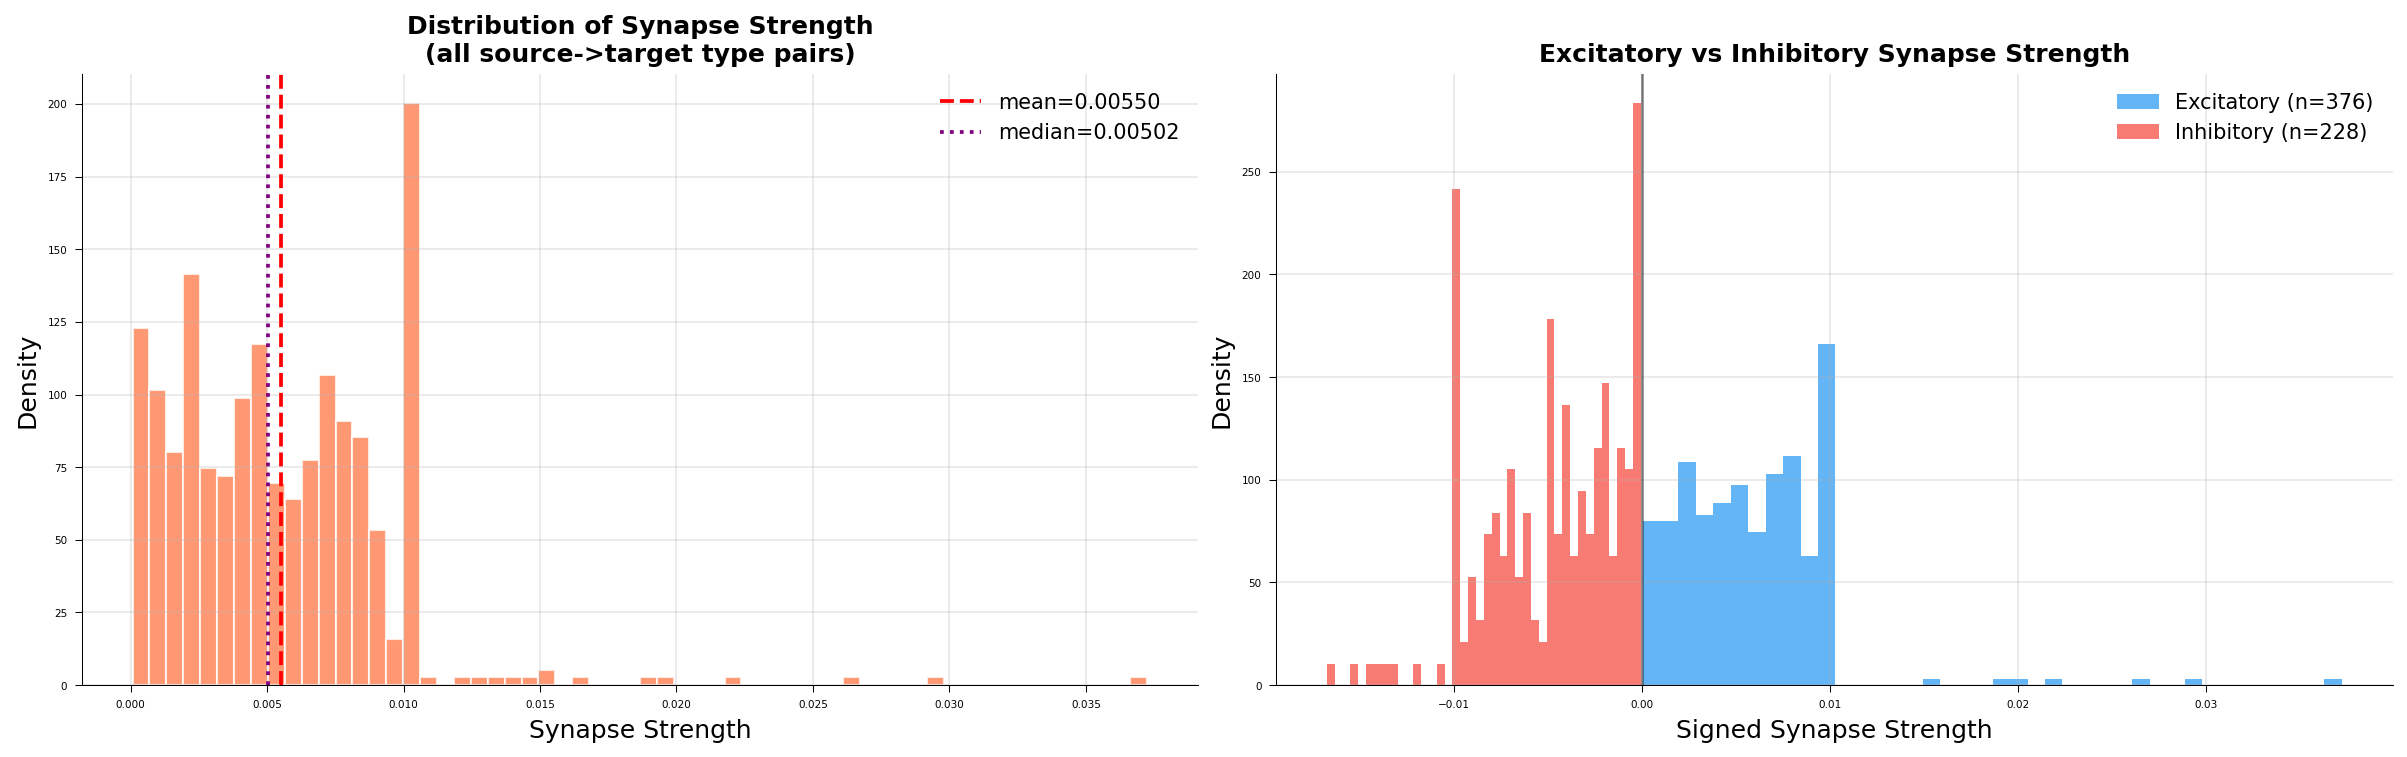

In [5]:
from IPython.display import Image
Image('outputs/04_syn_strength_distribution.png', width=900)


### 5. Synapse Strength 按 Source/Target Type 分解
Boxplot 展示各 type 作为 source 或 target 时的 strength 分布

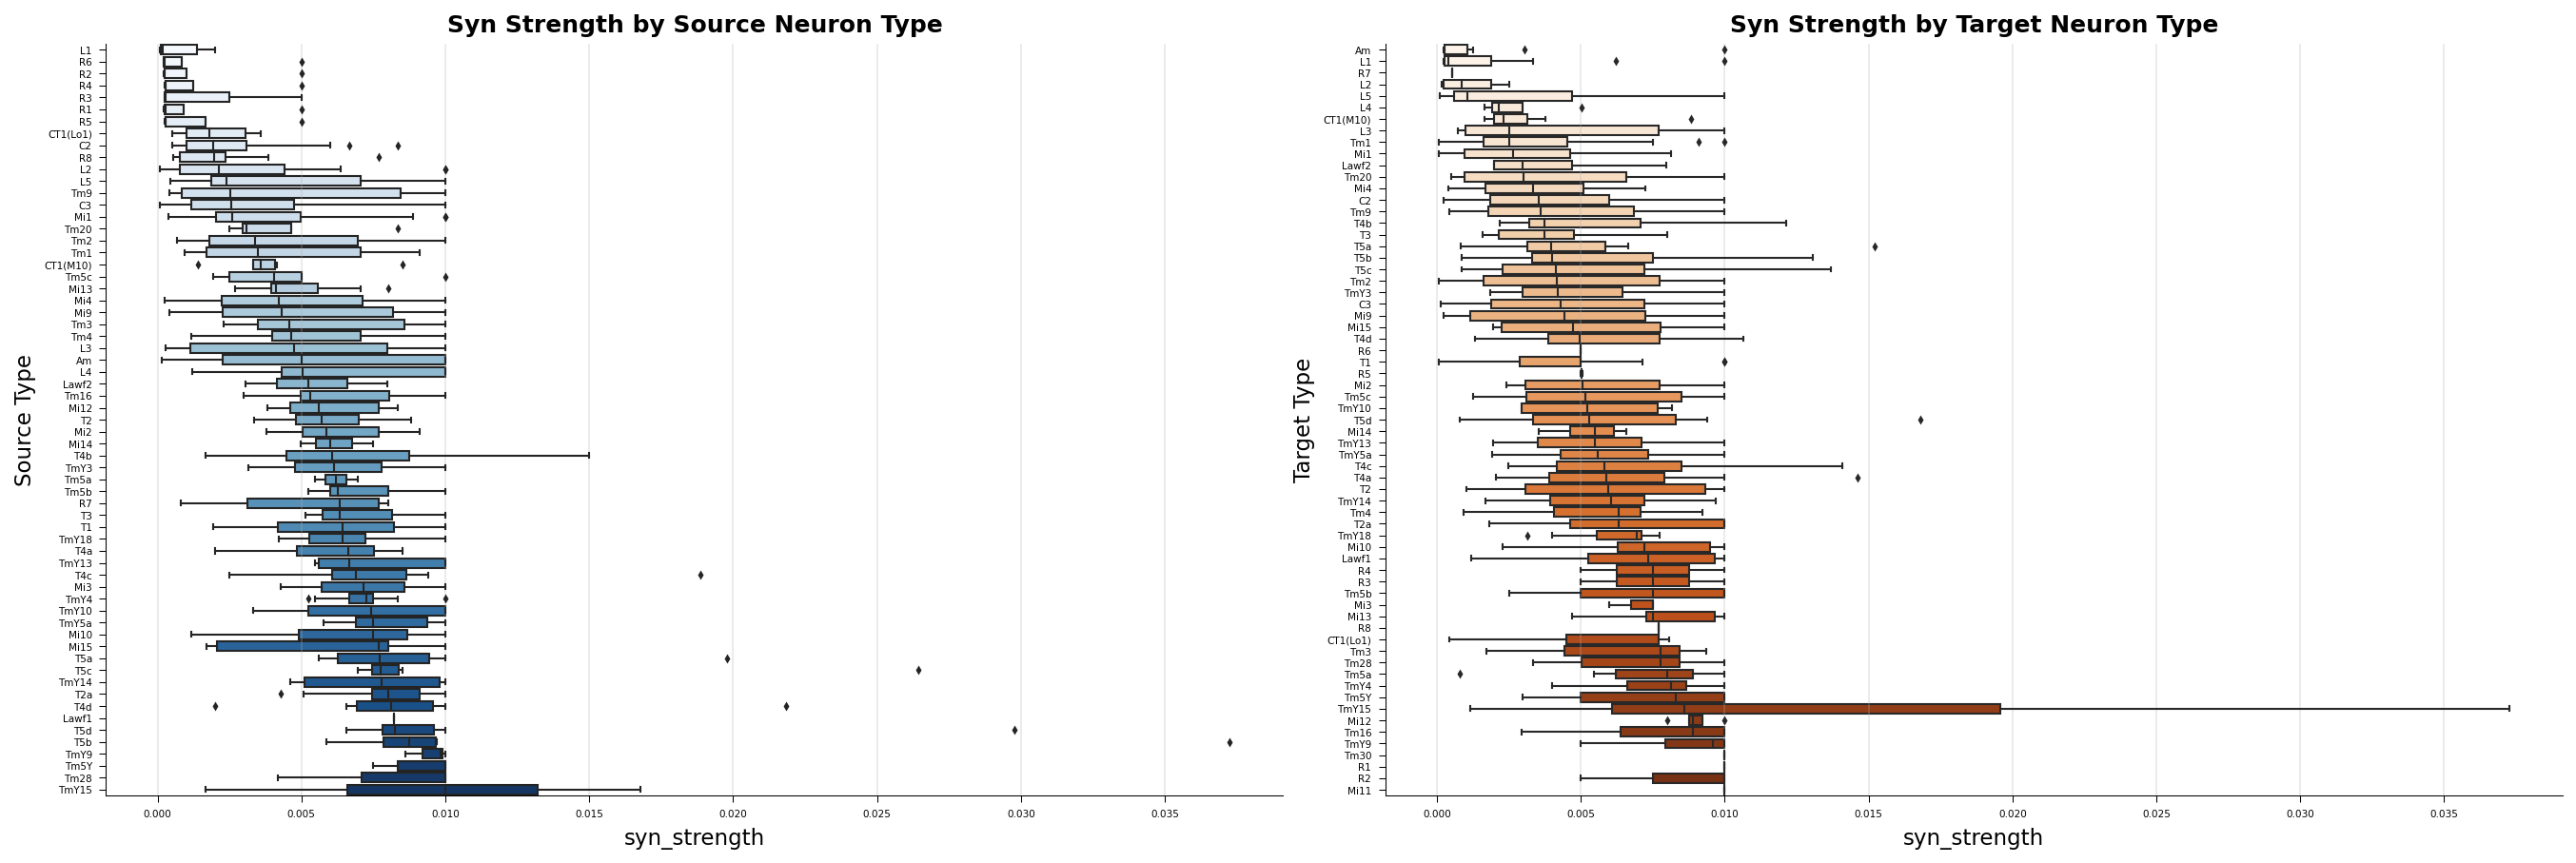

In [6]:
from IPython.display import Image
Image('outputs/05_syn_strength_by_type.png', width=900)


### 6. Synapse Count 分布
左：原始值；右：log 变换后分布（Lognormal 初始化，固定不训练）

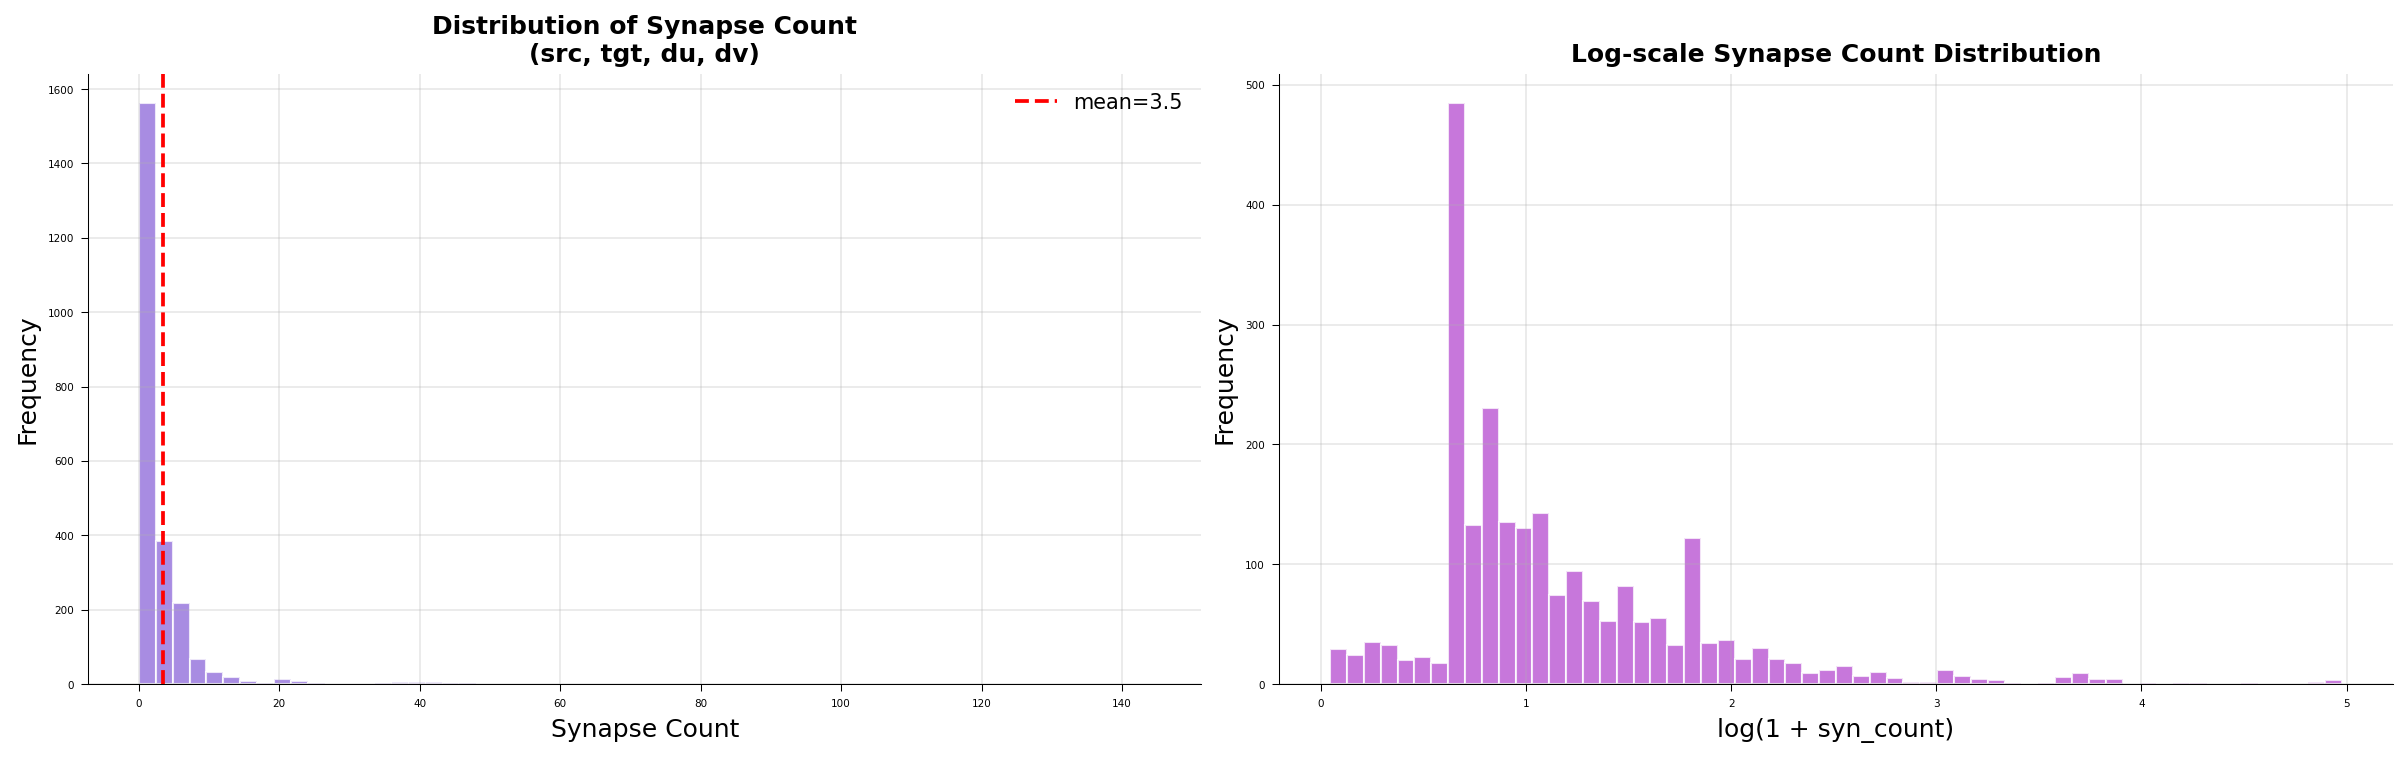

In [7]:
from IPython.display import Image
Image('outputs/06_syn_count_distribution.png', width=900)


### 7. Synapse Count 按 Source/Target Type 分解

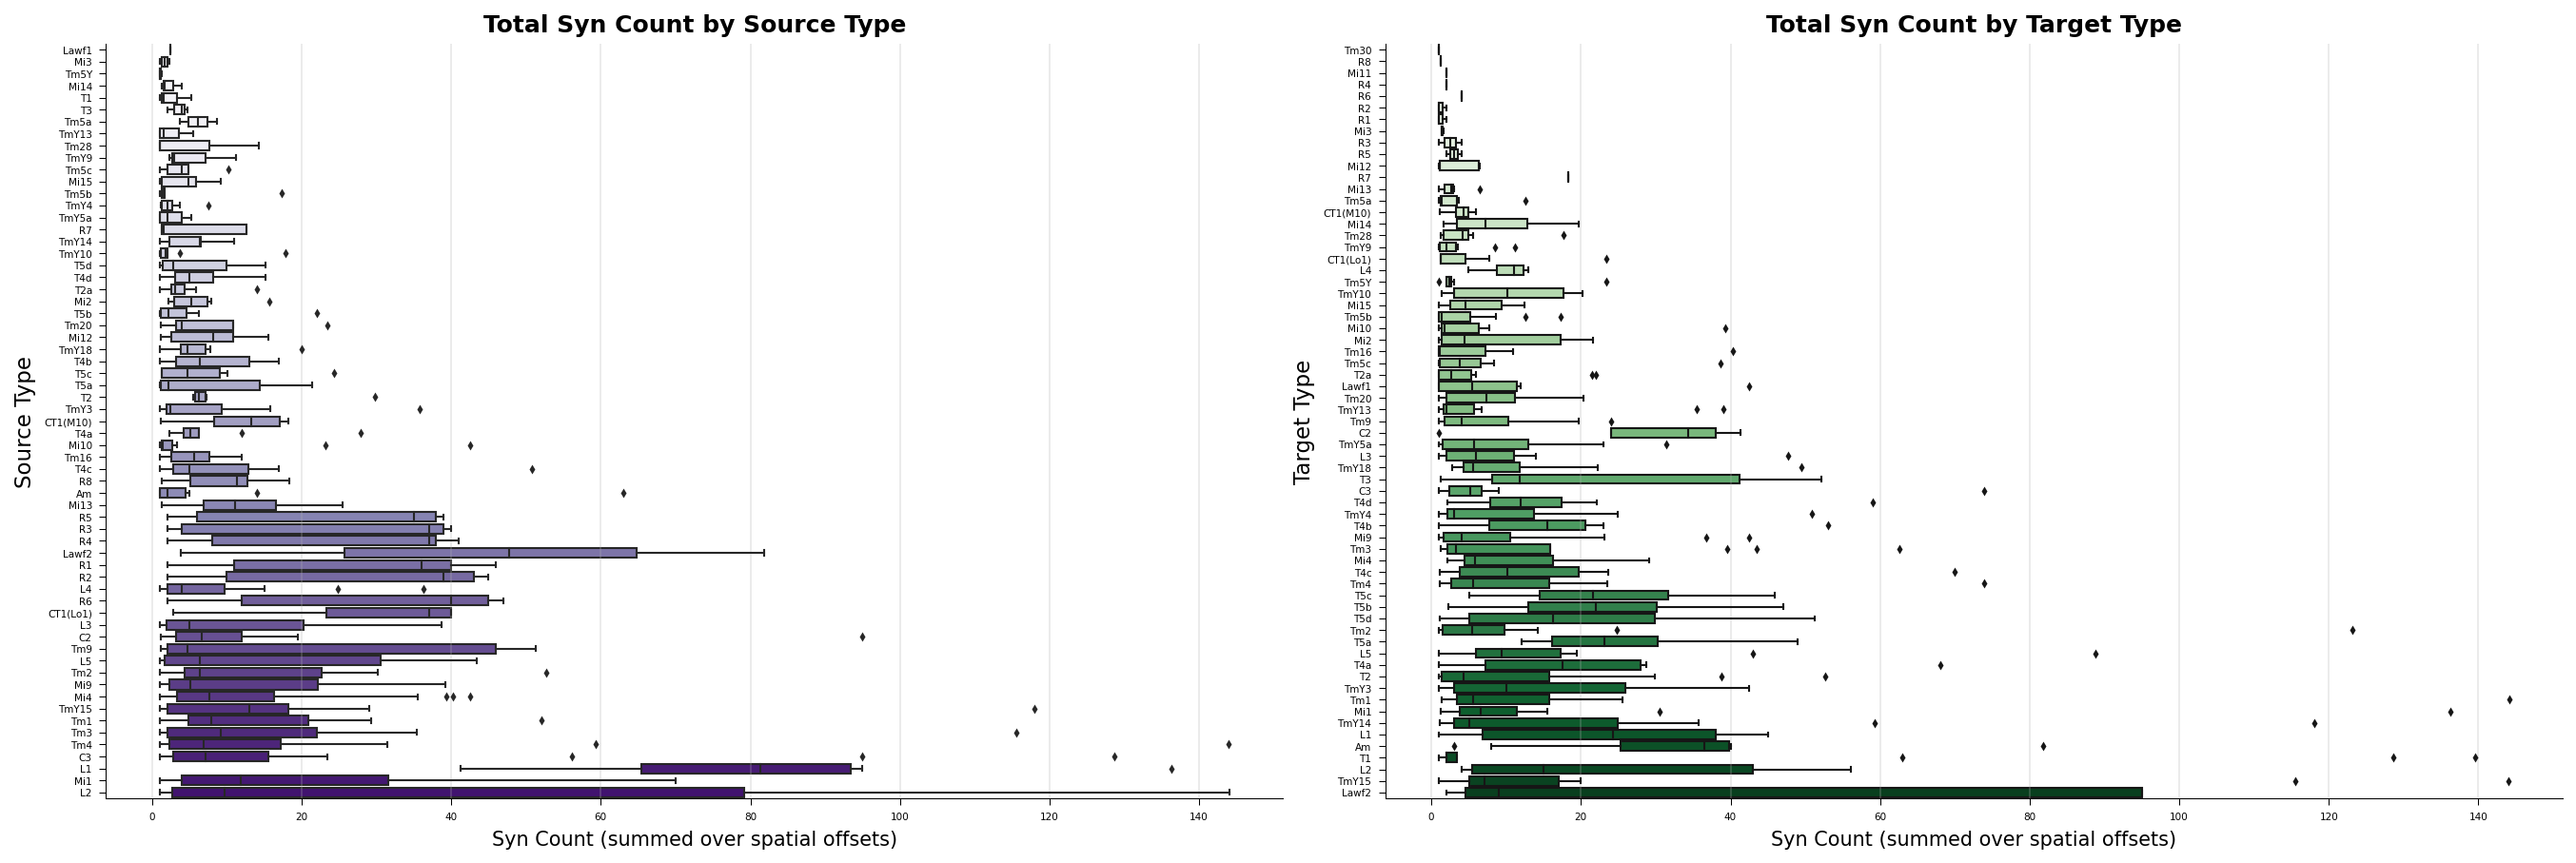

In [8]:
from IPython.display import Image
Image('outputs/07_syn_count_by_type.png', width=900)


### 8. Signed Synapse Strength 热力图
行=source type, 列=target type；蓝色=抑制, 红色=激励

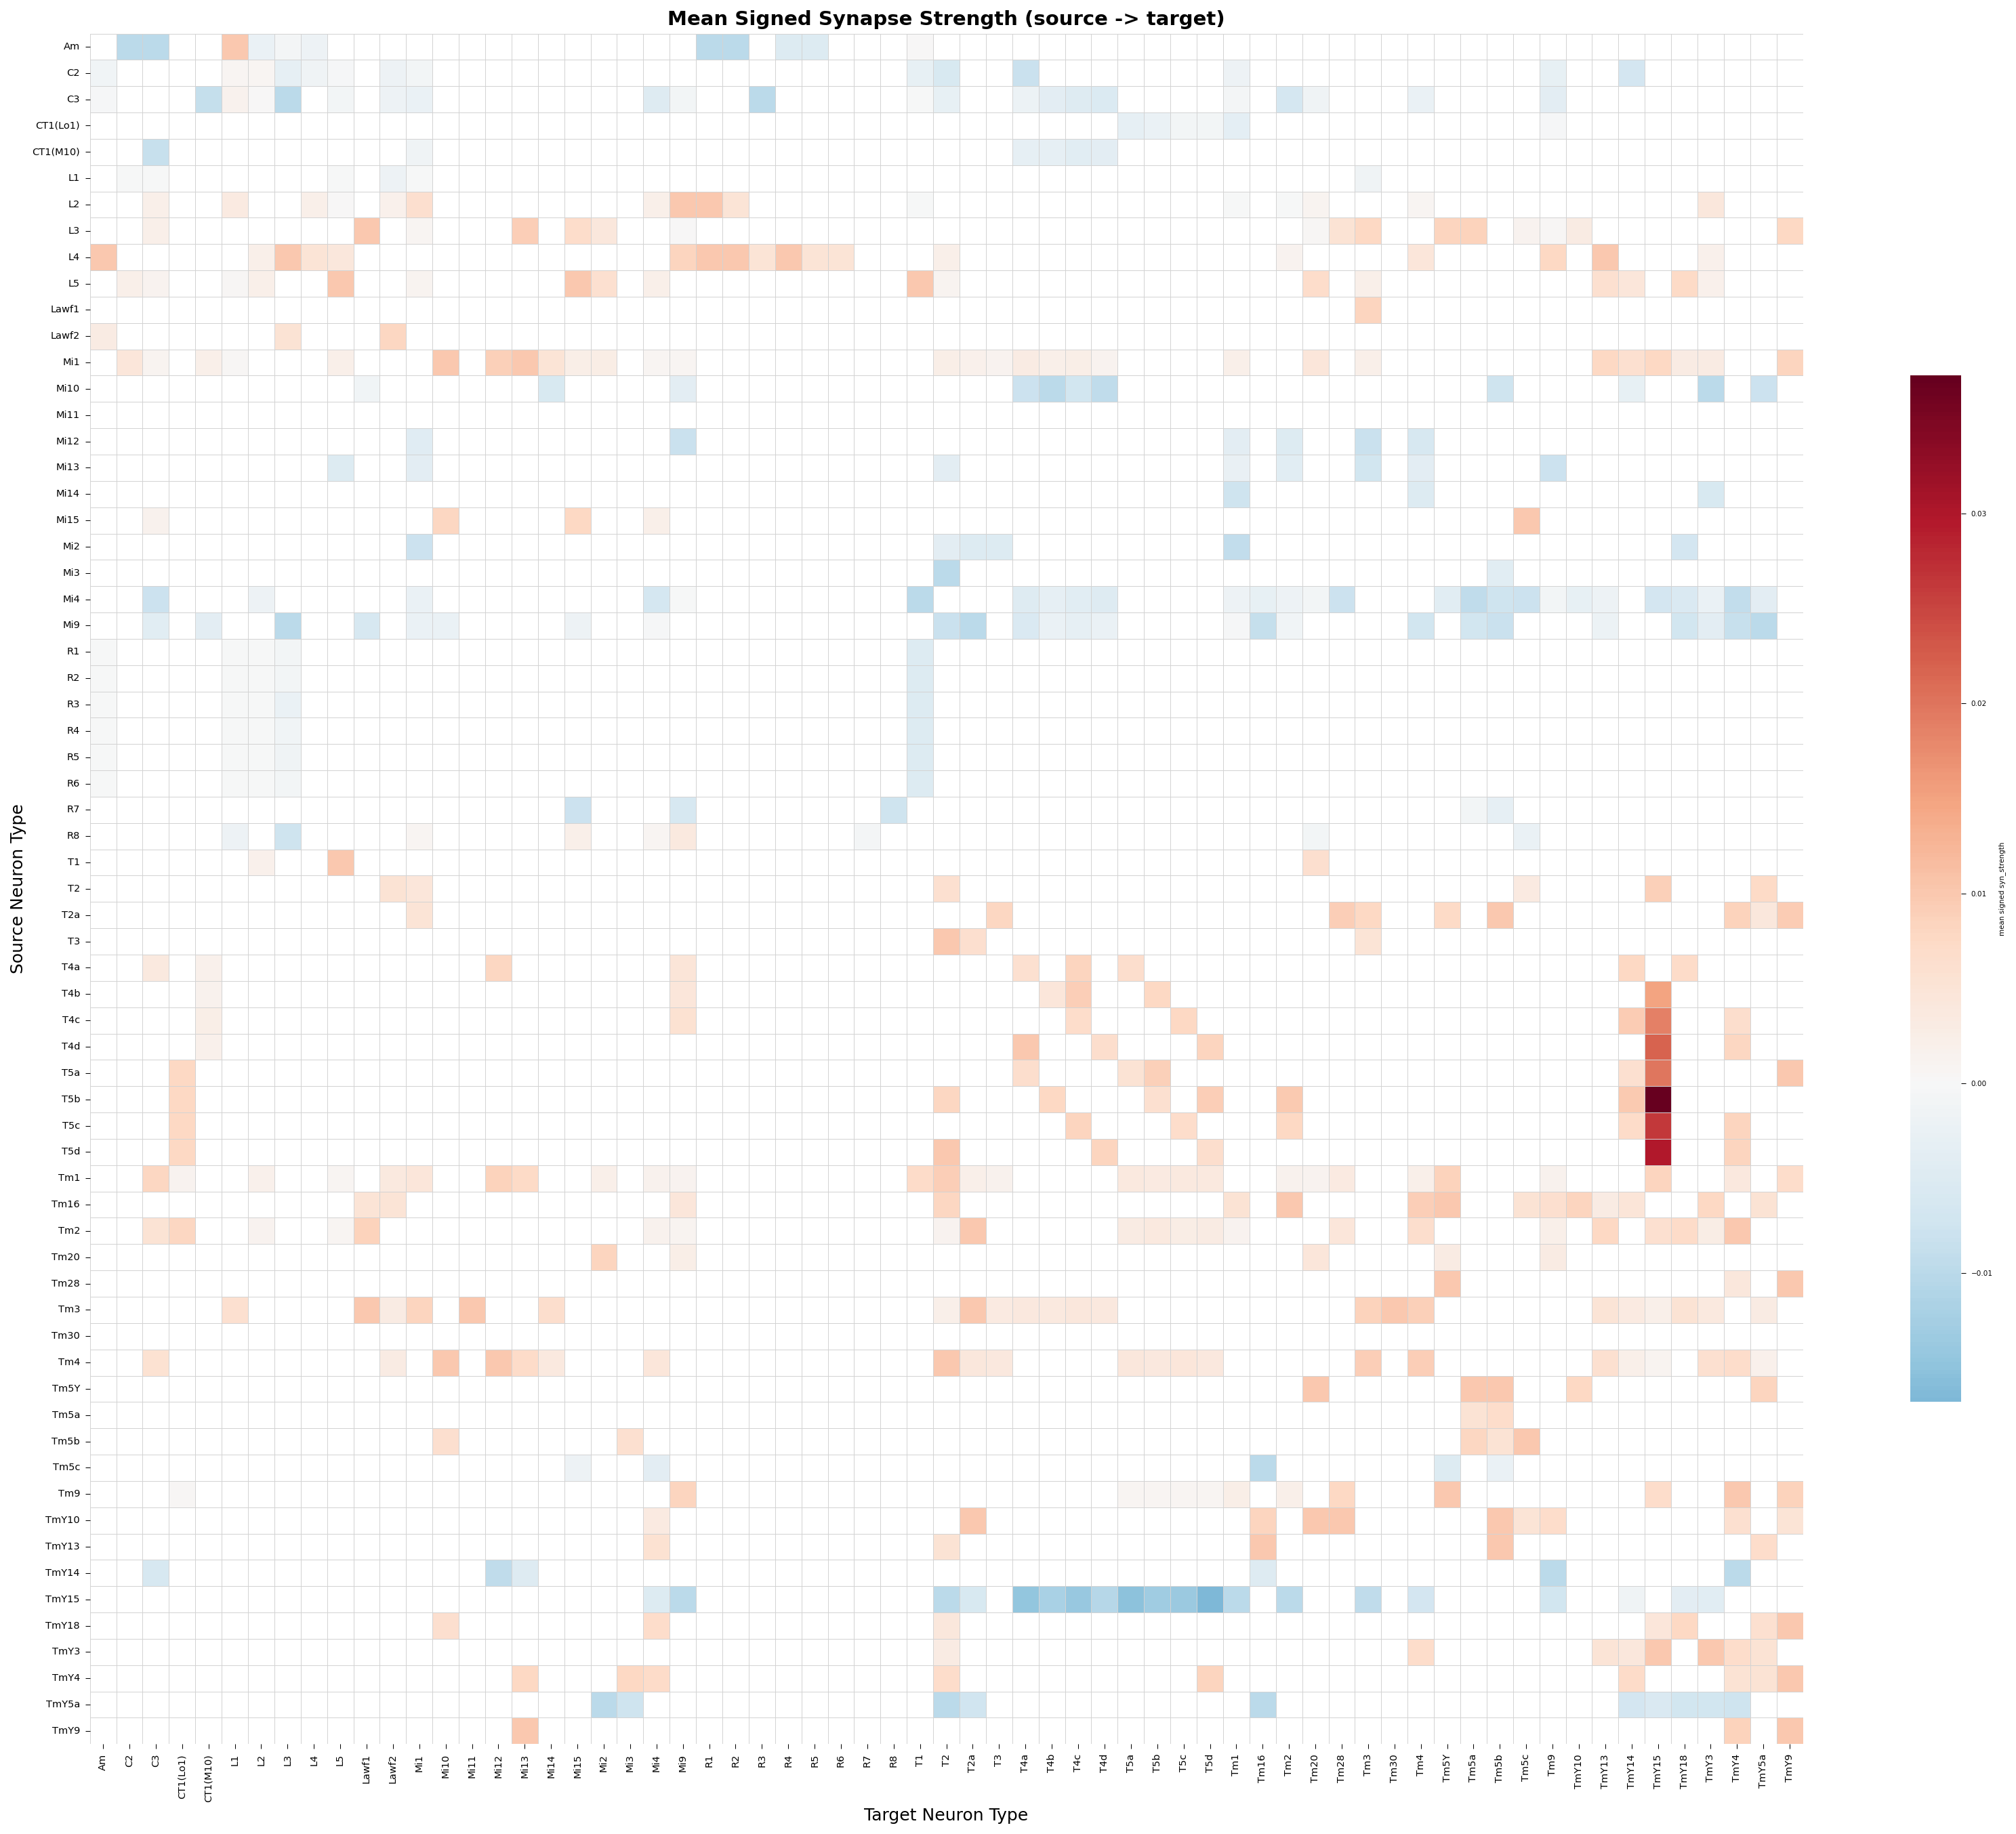

In [9]:
from IPython.display import Image
Image('outputs/08_syn_strength_heatmap.png', width=900)


### 9. 参数总览 (Summary)

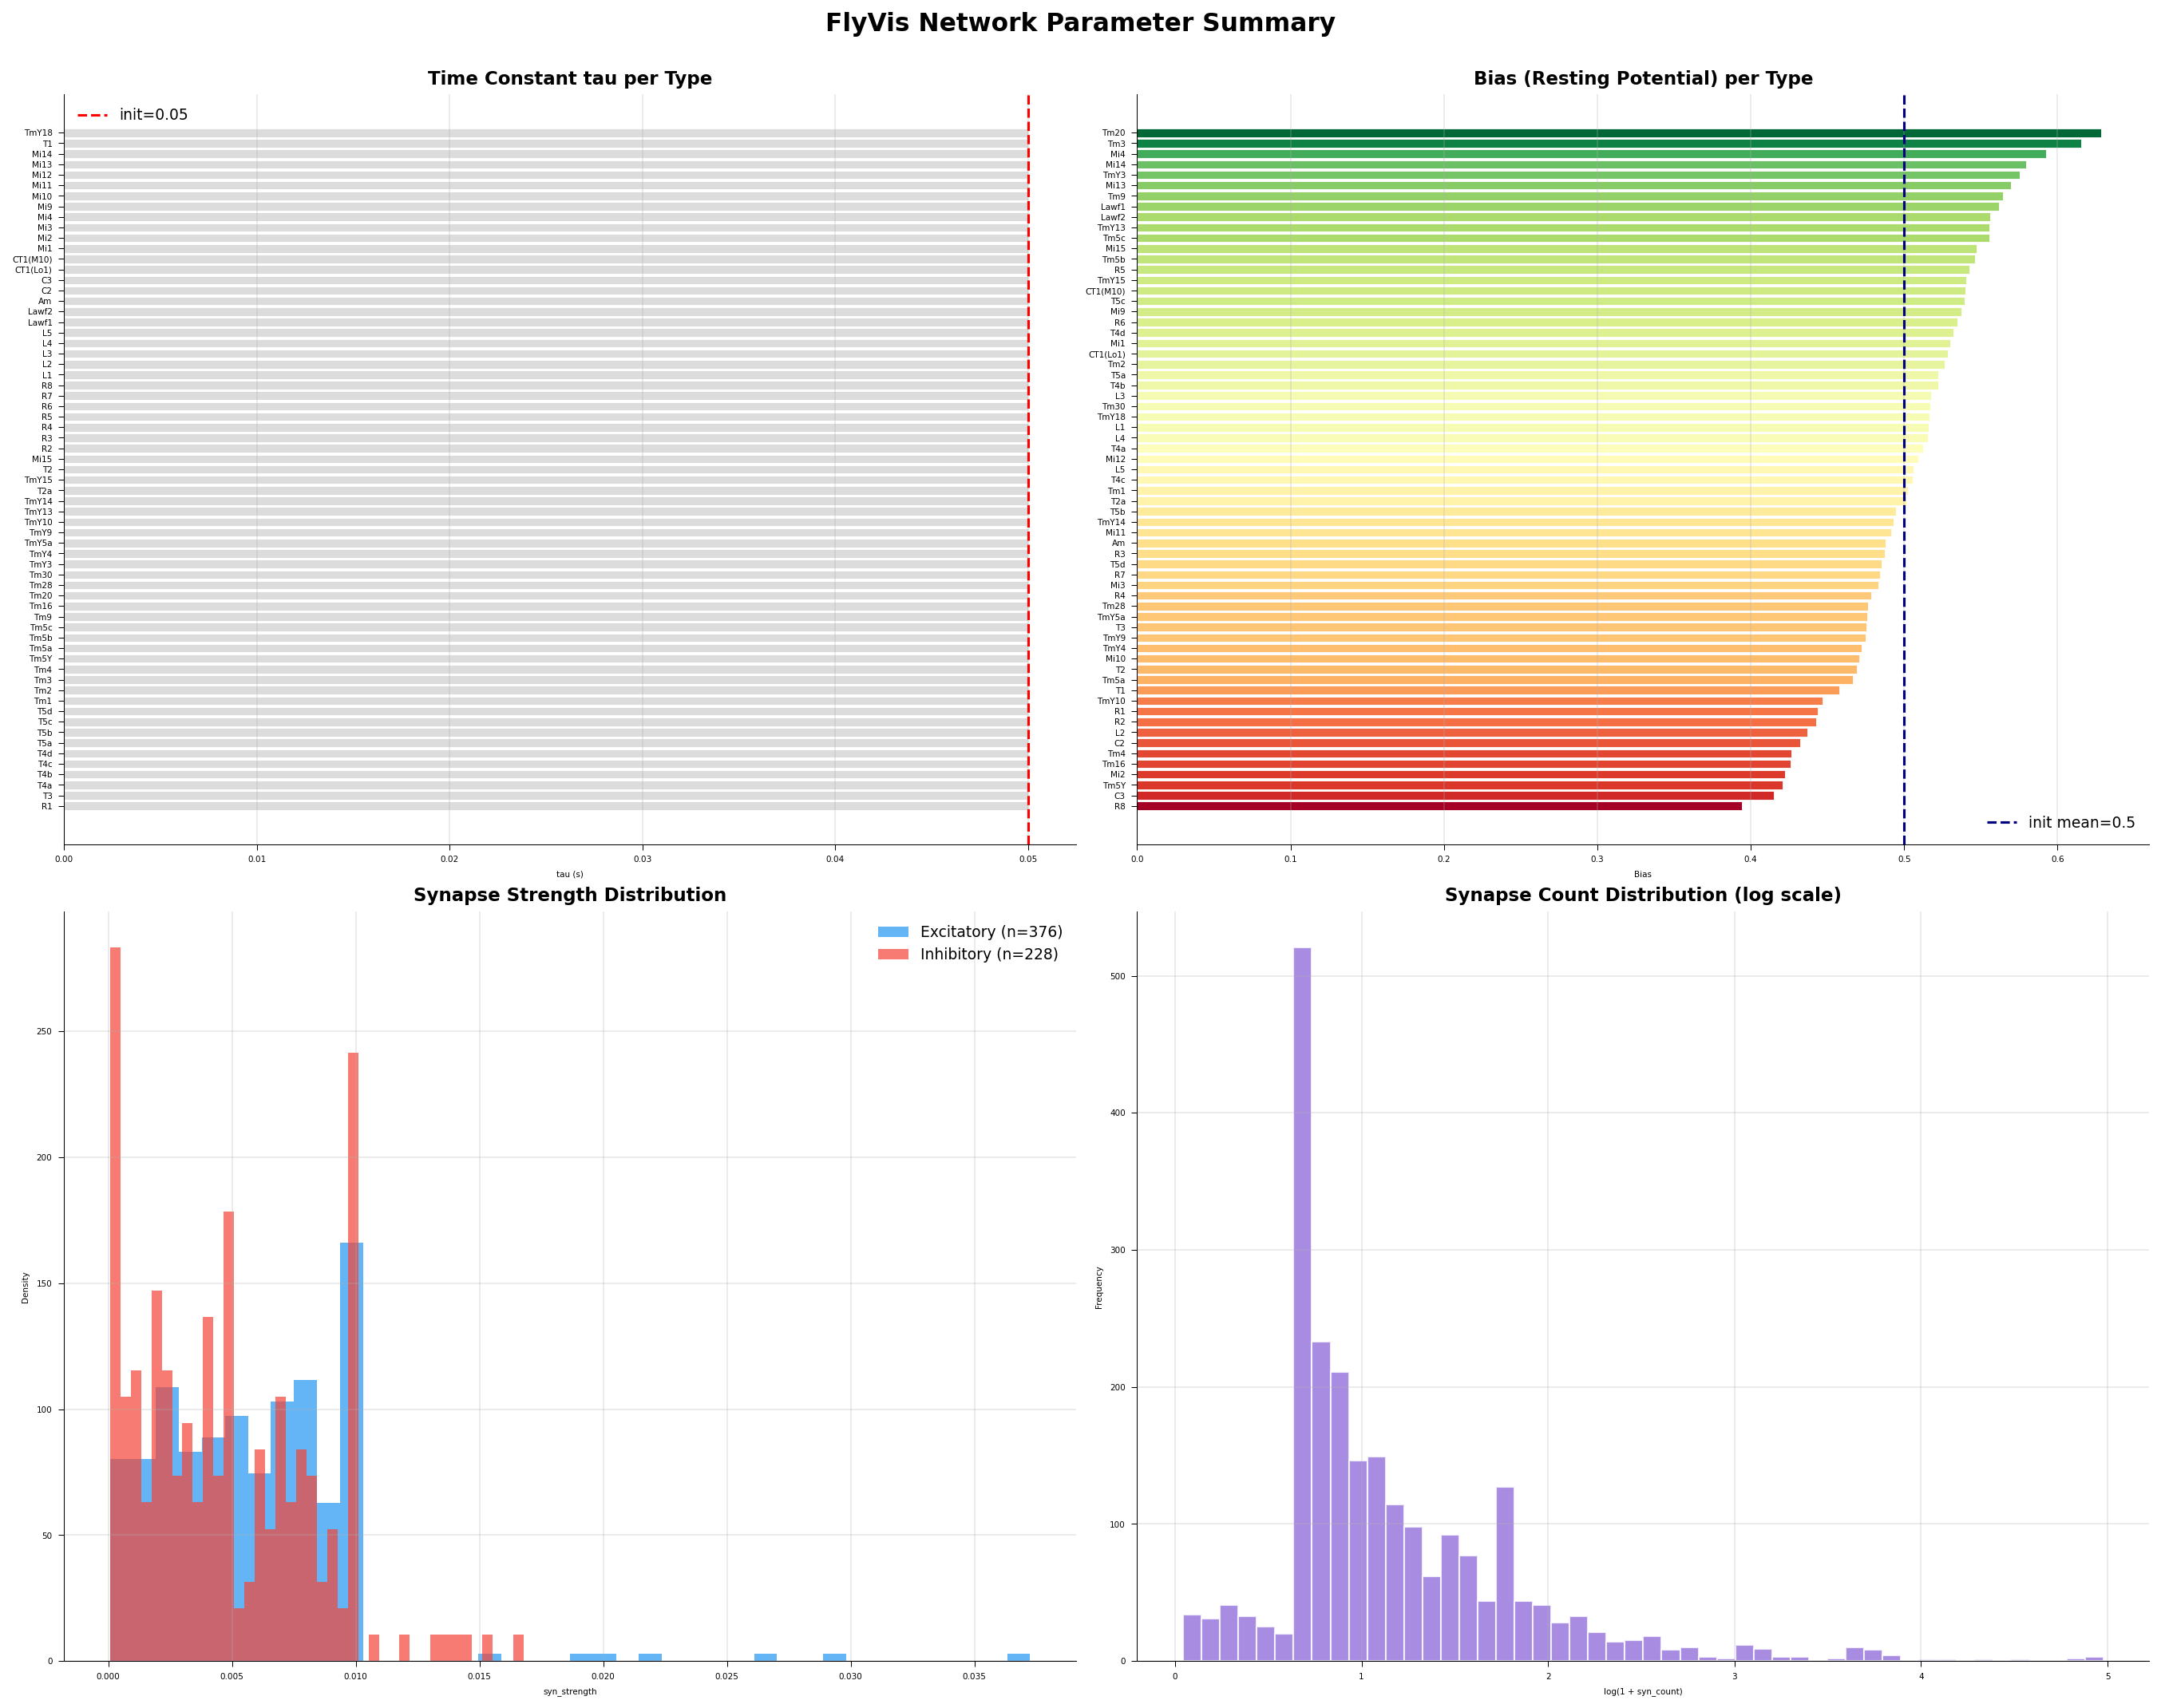

In [10]:
from IPython.display import Image
Image('outputs/09_parameter_summary.png', width=900)


## 交互式参数探索 (Interactive)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── τ 统计 ──
print('=== Time Constant tau ===')
print(df_nodes[['neuron_type','tau']].sort_values('tau').to_string(index=False))
print(f'All same: {df_nodes["tau"].nunique()==1}, mean={df_nodes["tau"].mean():.6f}, std={df_nodes["tau"].std():.8f}')


=== Time Constant tau ===


NameError: name 'df_nodes' is not defined

In [ ]:
# ── Bias 统计 ──
print('=== Bias (Resting Potential) ===')
print(df_nodes[['neuron_type','bias']].sort_values('bias').to_string(index=False))
print(f'mean={df_nodes["bias"].mean():.4f}, std={df_nodes["bias"].std():.4f}')


In [ ]:
# ── Top synapse connections by strength ──
print('=== Top 20 Strongest Synapse Connections ===')
df_top = df_edges.sort_values('syn_strength', ascending=False).head(20)
df_top['direction'] = df_top['sign'].apply(lambda s: 'EXC' if s>0 else 'INH')
print(df_top[['source_type','target_type','direction','syn_strength']].to_string(index=False))


In [ ]:
# ── Syn count: top connections ──
print('=== Top 20 Connections by Total Syn Count ===')
df_sc_top = (df_syn_count.groupby(['source_type','target_type'])['syn_count']
             .sum().reset_index()
             .sort_values('syn_count', ascending=False)
             .head(20))
print(df_sc_top.to_string(index=False))


In [ ]:
# ── Query: connections TO a specific neuron type ──
target = 'T4a'   # <-- change this
df_to = df_edges[df_edges['target_type'] == target].sort_values('signed_strength')
print(f'Inputs to {target} ({len(df_to)} connections):')
print(df_to[['source_type','sign','syn_strength','signed_strength']].to_string(index=False))


In [ ]:
# ── Query: connections FROM a specific neuron type ──
source = 'L1'   # <-- change this
df_from = df_edges[df_edges['source_type'] == source].sort_values('signed_strength')
print(f'Outputs from {source} ({len(df_from)} connections):')
print(df_from[['target_type','sign','syn_strength','signed_strength']].to_string(index=False))
